# BF-BOF post-combustion CCS steel NPV simulation

Run the Monte Carlo simulation for the BF-BOF post-combustion CCS steel retrofit and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "bf_bof_post_combustion_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,bf_bof_post_combustion_ccs,retrofit,sampled,1000000.0,20.0,777.006446,49.624507,315.742623,pci_coking_coal_mix,...,310.905352,5.602277,0.115,1.826761,204.949422,6.294114,4.837271,-0.099078,-4.423444,0.575466
1,1,bf_bof_post_combustion_ccs,retrofit,sampled,1000000.0,20.0,826.611255,49.100213,323.056344,pci_coking_coal_mix,...,318.423230,5.560944,0.115,1.802500,217.215769,7.979111,4.633114,-0.100664,-0.648173,0.658368
2,2,bf_bof_post_combustion_ccs,retrofit,sampled,1000000.0,20.0,739.384357,51.327797,323.569830,pci_coking_coal_mix,...,318.828665,5.521473,0.115,1.796994,224.469052,6.697420,4.741165,-0.092544,-4.123490,0.663920
3,3,bf_bof_post_combustion_ccs,retrofit,sampled,1000000.0,20.0,743.463191,52.272461,311.809984,pci_coking_coal_mix,...,307.173681,5.631100,0.115,1.836828,216.141525,7.290881,4.636303,-0.126120,-3.393524,0.582032
4,4,bf_bof_post_combustion_ccs,retrofit,sampled,1000000.0,20.0,916.413052,50.348490,333.687993,pci_coking_coal_mix,...,329.448749,5.583911,0.115,1.817066,227.557240,7.969402,4.239244,-0.109079,-1.654487,0.726105


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-2875.480555,742.874046,-292.874046
std,495.252144,50.442525,50.442525
min,-4597.122455,602.430177,-468.227076
5%,-3734.948440,666.073617,-380.412748
50%,-2844.145131,739.682464,-289.682464
95%,-2121.442627,830.412748,-216.073617
max,-1496.581950,918.227076,-152.430177


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


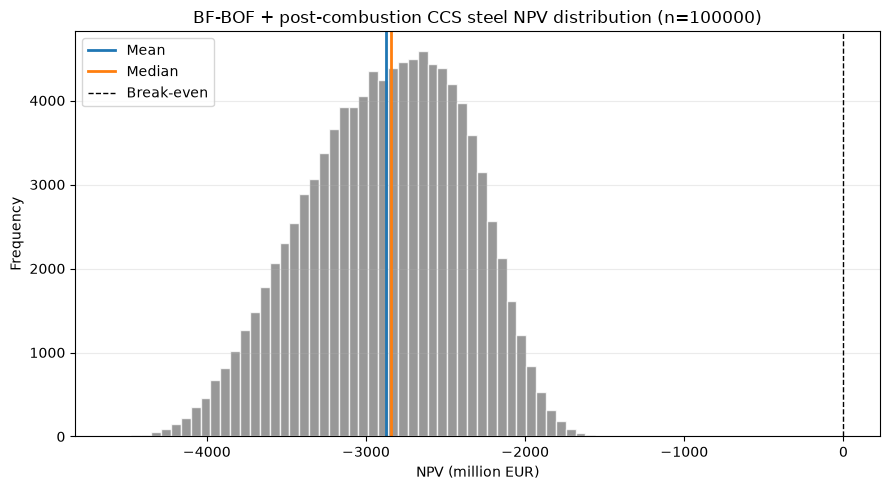

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"BF-BOF + post-combustion CCS steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


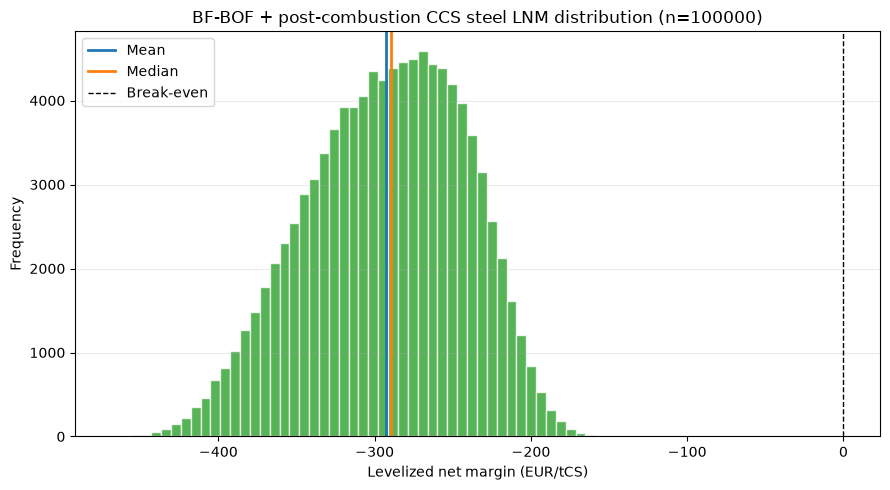

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"BF-BOF + post-combustion CCS steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


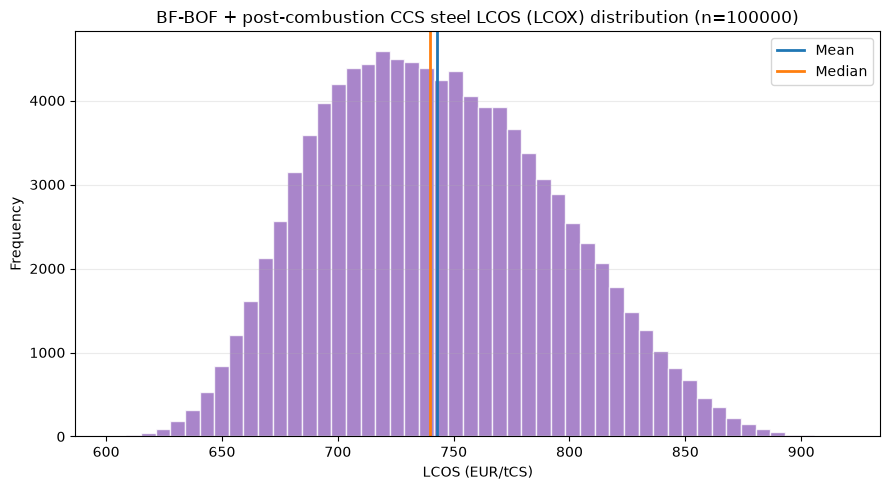

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"BF-BOF + post-combustion CCS steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_transport_and_storage_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur                       450.000000
annual_fixed_opex_eur                     50.097722
annual_variable_opex_eur                 317.780035
annual_fuel_cost_eur                     142.639096
annual_electricity_cost_eur               81.429215
annual_transport_and_storage_cost_eur     19.977698
annual_emissions_cost_eur                 49.484202
annual_net_cash_flow_eur                -211.407967
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    "capex_change_eur_per_tcs",
    "fixed_opex_change_eur_per_tcs",
    "variable_opex_change_eur_per_tcs",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_tcs",
    "bau_fixed_opex_eur_per_tcs",
    "bau_variable_opex_eur_per_tcs",
    "bau_fuel_consumption_mwh_th_per_tcs",
    "bau_electricity_consumption_mwh_per_tcs",
    "bau_emissions_tco2_per_tcs",
    "transport_and_storage_share_of_capture_cost",
    "capture_cost_excluding_transport_and_storage_eur_per_tcs",
    "transport_and_storage_cost_eur_per_tcs",
]

available_retrofit_columns = [
    column for column in retrofit_columns if column in results
]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_tcs,bau_fixed_opex_eur_per_tcs,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,transport_and_storage_share_of_capture_cost,capture_cost_excluding_transport_and_storage_eur_per_tcs,transport_and_storage_cost_eur_per_tcs
count,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,204.086657,7.096684,4.499689,-1.100547e-01,-2.855703,0.660131,595.759311,43.001037,313.280347,5.586838,1.150000e-01,1.819993,1.870000e-01,106.832610,19.977698
std,15.579848,0.577273,0.231001,6.362872e-02,1.643687,0.049560,70.249108,1.635479,15.316140,0.081950,1.387786e-17,0.020388,2.775571e-17,38.241761,7.151209
min,177.000251,6.100008,4.100003,-2.199926e-01,-5.699980,0.520912,425.825143,39.015064,270.332822,5.400847,1.150000e-01,1.770230,1.870000e-01,30.218363,5.650834
5%,179.732080,6.200292,4.140220,-2.091372e-01,-5.413476,0.566801,479.313339,40.264788,284.463227,5.457025,1.150000e-01,1.785840,1.870000e-01,50.580106,9.458480
50%,204.167623,7.096746,4.498852,-1.102582e-01,-2.859395,0.668745,594.655388,42.995772,315.901316,5.580827,1.150000e-01,1.819980,1.870000e-01,104.388632,19.520674
95%,228.330504,8.001940,4.860137,-1.097460e-02,-0.293274,0.724801,714.360209,45.740355,333.352447,5.730403,1.150000e-01,1.854135,1.870000e-01,173.296602,32.406465
max,230.999282,8.099970,4.899999,-5.898744e-08,-0.000019,0.730000,768.957094,46.996992,334.999646,5.799559,1.150000e-01,1.869842,1.870000e-01,223.624039,41.817695
